# General introduction (Symbolic Regression)
## Idea
Use CGP to construct more complex features $X'$ and use them to predict a $y$ target rather than the raw $X$.

## Problems considered
Same as PPSN paper on constants optimization.
| Dataset | Samples | Features | Train | Test |
| --- | --- | --- | --- | --- |
| Tecator | 240 | 124 | - | - |
| Geographical Origin Music | 1059 | 117 | - | - |
| Chemical Competition | 1066 | 57 | 710  | 356   | `
| Chemical Tower       | 4999 | 25 | 3135 | 1864  |
| Friction Dynamic     | 2017 | 17 | 1008 | 1009  |
| Friction Static      | 2017 | 16 | 1008 | 1009  |
| NASA Battery 1       | 635  | 6  | 503  | 132   |
| NASA Battery 2       | 1638 | 5  | 1099 | 539   |
| Flow Stress          | 7800 | 2  | 4199 | 3601  |
| Nikuradse 1          | 361  | 2  | 229  | 132   | 
| Nikuradse 2          | 362  | 1  | 199  | 163   |

## Baselines
- Operon (SOTA on symbolic regression) $\rightarrow$ `Operon`
- Ridge regression from $X$ to $y$ $\rightarrow$ `ridge`
- Tree GP (tinygp version) $\rightarrow$ `tinygp`

## CGP versions considered
- Standard CGP (from $X$ to $y$) $\rightarrow$ `standard`
- CGP with linear scaling (from $X$ to $y$) $\rightarrow$ `linscal`
- CGP used for feature construction ($X$ to $X'$) followed by Ridge regression ($X'$ to $y$) $\rightarrow$ `feats`
- As previous, with addition of bias term in Ridge regression $\rightarrow$ `featsls`
- CGP used for feature construction ($X$ to $X'$) followed by another CGP for regression ($X'$ to $y$) $\rightarrow$ `seq`

For `standard`, `linscal`, `feats`, and `featsls` experimented with both 50 and 100 nodes (when not specified it is 50) for the CGP part.
For `seq` experimented with 50 nodes for each part of the pipeline.

## Number of features
By default, the number of intermediate features $|X'|$ is set by default to round$(\sqrt{|X|})$.
For the Chemical Competition problem also studied the impact of features numbers.

In [95]:
from copy import copy
import scikit_posthocs as sp

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

from scipy.stats import mannwhitneyu
import numpy as np

sns.set_theme()
warnings.filterwarnings('ignore')

In [96]:
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)

In [97]:
problems = ["4544_GeographicalOriginalofMusic", "505_tecator",
            "chemical_2_competition", "chemical_1_tower", "friction_dyn_one-hot", "friction_stat_one-hot",
            "nasa_battery_1_10min", "nasa_battery_2_20min", "flow_stress_phip0.1", "nikuradse_1",
            "nikuradse_2", ]

# Performance

In [98]:
dfs = []
missing = 0
missing_configs = []
for problem in problems:
    try:
        tmp_df = pd.read_csv(f"../results/ridge_{problem}.csv")
        tmp_df["seed"] = 0
        tmp_df["problem"] = problem
        tmp_df["algo"] = "ridge"
        tmp_df["method"] = "baseline"
        tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
        dfs.append(tmp_df)
    except FileNotFoundError:
        pass
    for seed in range(30):
        for method in ["CGP", "CGP_100"]:
            for extra in ['linscal', 'feats', 'featsls', 'baseline', 'seq']:
                if os.path.exists(f"../results/{method}_{extra}_{problem}_{seed}.pickle"):
                    tmp_df = pd.read_csv(f"../results/{method}_{extra}_{problem}_{seed}.csv")
                    tmp_df["seed"] = seed
                    tmp_df["problem"] = problem
                    tmp_df["algo"] = extra.replace("baseline", "standard")
                    tmp_df["method"] = method
                    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                    dfs.append(tmp_df)
df = pd.concat(dfs, ignore_index=True)
df["test_accuracy"] = df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,method,total_time
0,0,0.467627,0.000000,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,0
1,1,0.467627,2.229542,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,2
2,2,0.467627,0.847836,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,3
3,3,0.467627,0.858655,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,3
4,4,0.520527,0.890538,0.543087,0,4544_GeographicalOriginalofMusic,linscal,CGP,4


In [99]:
operon_dfs = []
for problem in problems:
    for seed in range(30):
        try:
            tmp_df = pd.read_csv(f"../results/operon_{problem}_{seed}.csv")
            tmp_df["seed"] = seed
            tmp_df["problem"] = problem
            tmp_df["algo"] = "Operon"
            tmp_df["method"] = "baseline"
            tmp_df["total_time"] = 0
            operon_dfs.append(tmp_df)
        except FileNotFoundError:
            pass
operon_df = pd.concat(operon_dfs, ignore_index=True)
operon_df = operon_df.rename(columns={"test_accuracy": "accuracy"})
operon_df = operon_df.drop(columns=["max_fitness"])
operon_df["when"] = "test"
operon_df

,accuracy,size,seed,problem,algo,method,total_time,when
0,0.743217,52.0,0,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
1,0.707671,54.0,1,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
2,0.717872,51.0,2,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
3,0.789682,54.0,3,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
4,0.774544,51.0,4,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
5,0.762122,53.0,5,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
6,0.701471,51.0,6,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
7,0.721217,54.0,7,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
8,0.680493,54.0,8,4544_GeographicalOriginalofMusic,Operon,baseline,0,test
9,0.696688,50.0,9,4544_GeographicalOriginalofMusic,Operon,baseline,0,test


In [100]:
baselines_list = ["Operon", "tinygp"]  # "QLattice", "PySR", "eggp"]
# baselines_list = ["Operon"]
baselines_df1 = pd.read_csv("baselines.csv")
baselines_df2 = pd.read_csv("baselines_tinygp.csv")
baselines_df = pd.concat([baselines_df1, baselines_df2], ignore_index=True)
baselines_df.rename(columns={
    "run": "seed",
    "algorithm": "algo",
    "r2_test": "accuracy",
    "dataset": "problem",
}, inplace=True)
baselines_df = baselines_df[["seed", "algo", "accuracy", "problem"]]
baselines_df = baselines_df[baselines_df["algo"].isin(baselines_list)]
baselines_df = baselines_df[baselines_df["problem"].isin(problems)]
baselines_df["method"] = "baseline"
baselines_df.head()

,seed,algo,accuracy,problem,method
4756,0,Operon,0.917246,chemical_1_tower,baseline
4757,1,Operon,0.915317,chemical_1_tower,baseline
4758,2,Operon,0.911019,chemical_1_tower,baseline
4759,3,Operon,0.914184,chemical_1_tower,baseline
4760,4,Operon,0.912897,chemical_1_tower,baseline


In [101]:
df1 = copy(df)
df2 = copy(df)
df1 = df.rename(columns={"test_accuracy": "accuracy"})
df2 = df.rename(columns={"max_fitness": "accuracy"})
df1 = df1.drop(columns=["max_fitness"])
df2 = df2.drop(columns=["test_accuracy"])
df1["when"] = "test"
df2["when"] = "train"
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,iteration,time,accuracy,seed,problem,algo,method,total_time,when
0,0,0.000000,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,0,test
1,1,2.229542,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,2,test
2,2,0.847836,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,3,test
3,3,0.858655,0.320843,0,4544_GeographicalOriginalofMusic,linscal,CGP,3,test
4,4,0.890538,0.543087,0,4544_GeographicalOriginalofMusic,linscal,CGP,4,test


In [102]:
max_iter = df.groupby(["algo", "problem"])["iteration"].transform("max")
final_df = df[df["iteration"] == max_iter].reset_index(drop=True)
final_df.head()

,iteration,time,accuracy,seed,problem,algo,method,total_time,when
0,1499,0.917527,0.543087,0,4544_GeographicalOriginalofMusic,linscal,CGP,1404,test
1,1499,0.983366,0.788091,0,4544_GeographicalOriginalofMusic,feats,CGP,1527,test
2,1499,0.914449,0.784938,0,4544_GeographicalOriginalofMusic,featsls,CGP,1518,test
3,1499,0.813667,0.506295,0,4544_GeographicalOriginalofMusic,standard,CGP,1163,test
4,1499,0.951035,0.728521,1,4544_GeographicalOriginalofMusic,linscal,CGP,1452,test


In [103]:
final_df_for_baseline_merge = final_df[final_df["when"] == "test"][["seed", "algo", "method", "problem", "accuracy"]]
baselines_df_filtered = baselines_df[baselines_df["problem"].isin(final_df_for_baseline_merge["problem"])]
final_df_and_baseline = pd.concat([final_df_for_baseline_merge, baselines_df_filtered, operon_df], ignore_index=True)
final_df_and_baseline.head()

,seed,algo,method,problem,accuracy,size,total_time,when
0,0,linscal,CGP,4544_GeographicalOriginalofMusic,0.543087,NaN,NaN,NaN
1,0,feats,CGP,4544_GeographicalOriginalofMusic,0.788091,NaN,NaN,NaN
2,0,featsls,CGP,4544_GeographicalOriginalofMusic,0.784938,NaN,NaN,NaN
3,0,standard,CGP,4544_GeographicalOriginalofMusic,0.506295,NaN,NaN,NaN
4,1,linscal,CGP,4544_GeographicalOriginalofMusic,0.728521,NaN,NaN,NaN


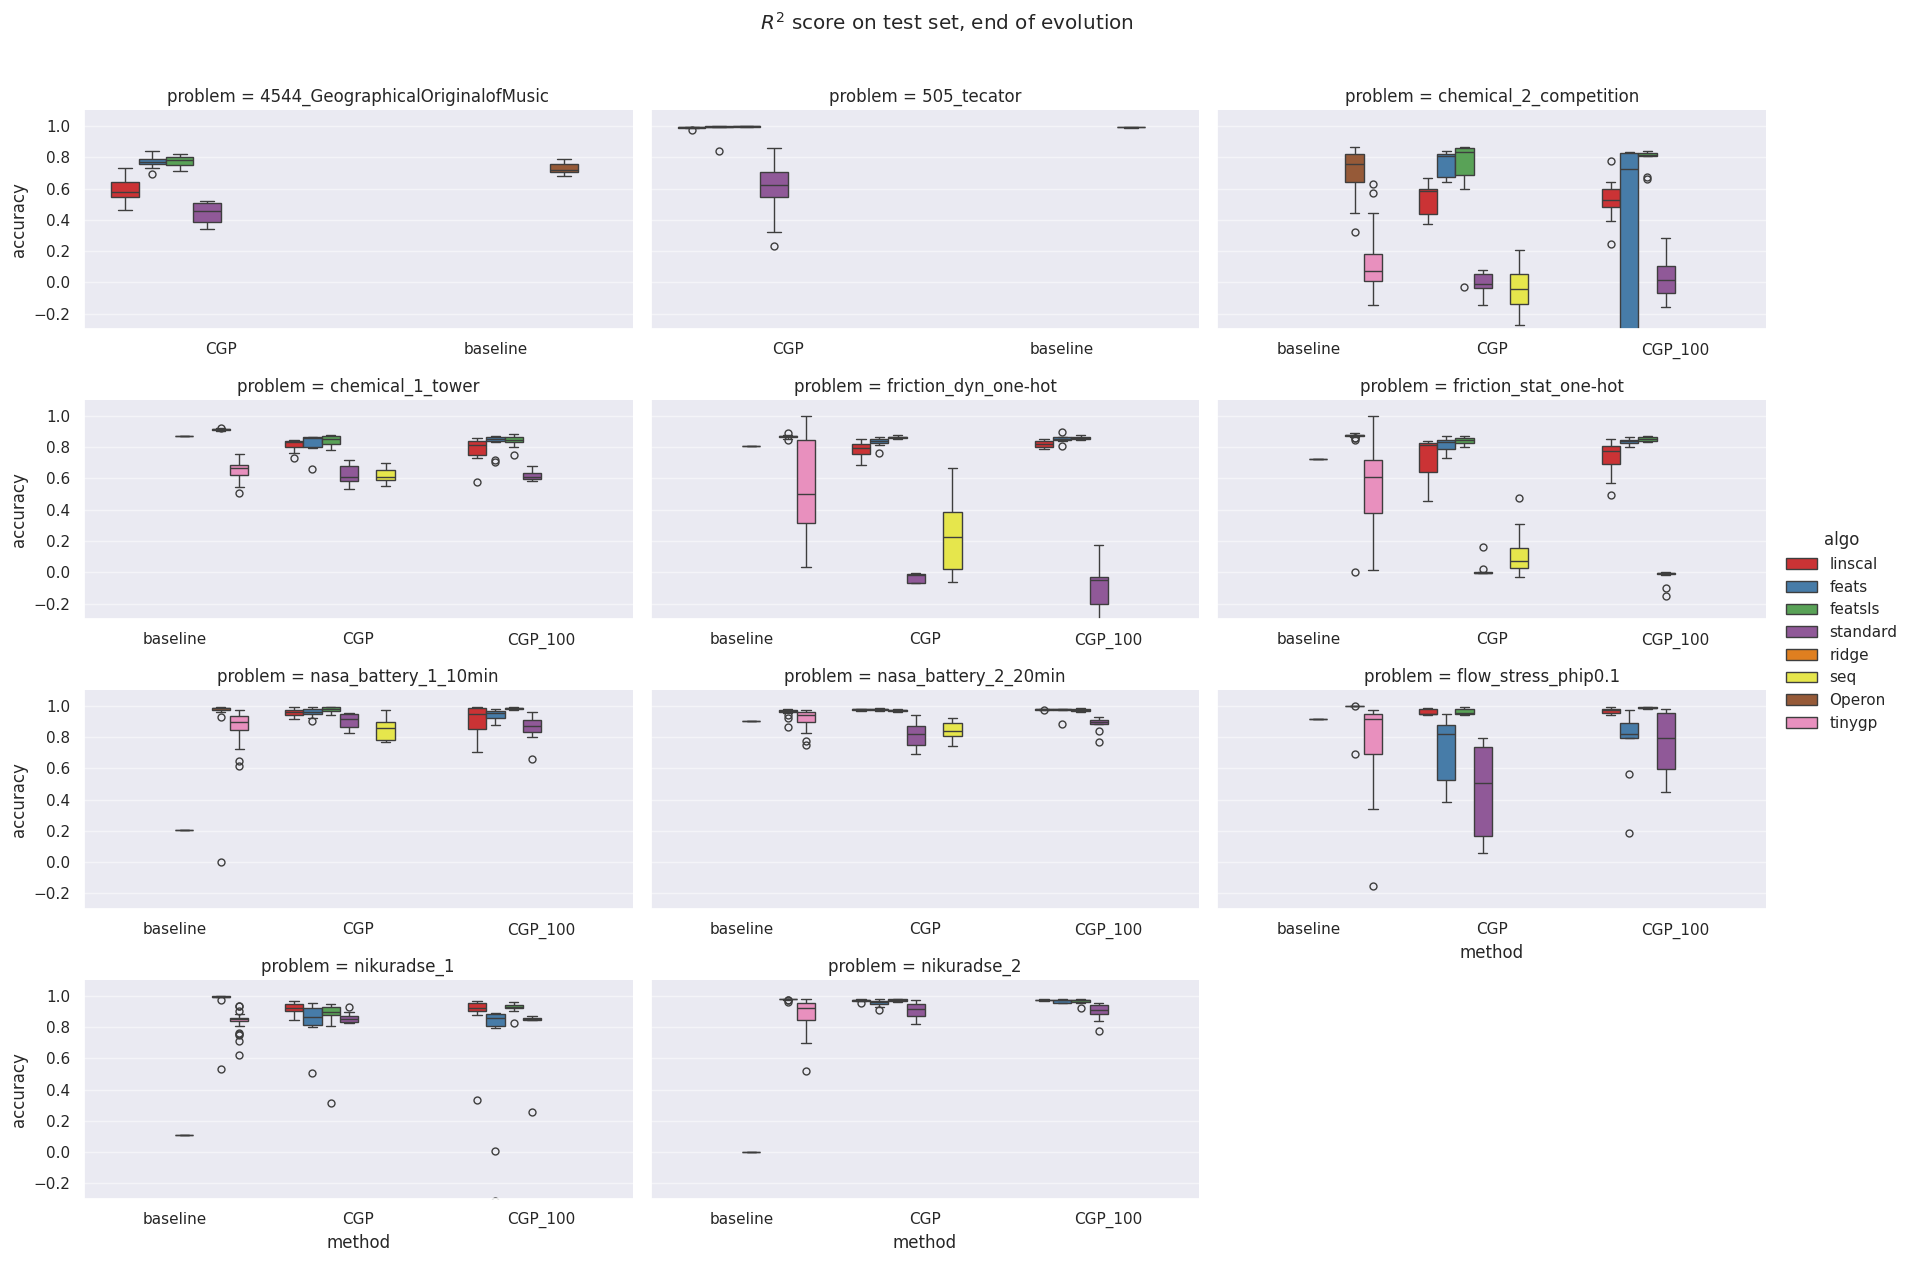

In [104]:
g = sns.catplot(x="method", y="accuracy", hue="algo", data=final_df_and_baseline, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(-.3, 1.1)
plt.show()

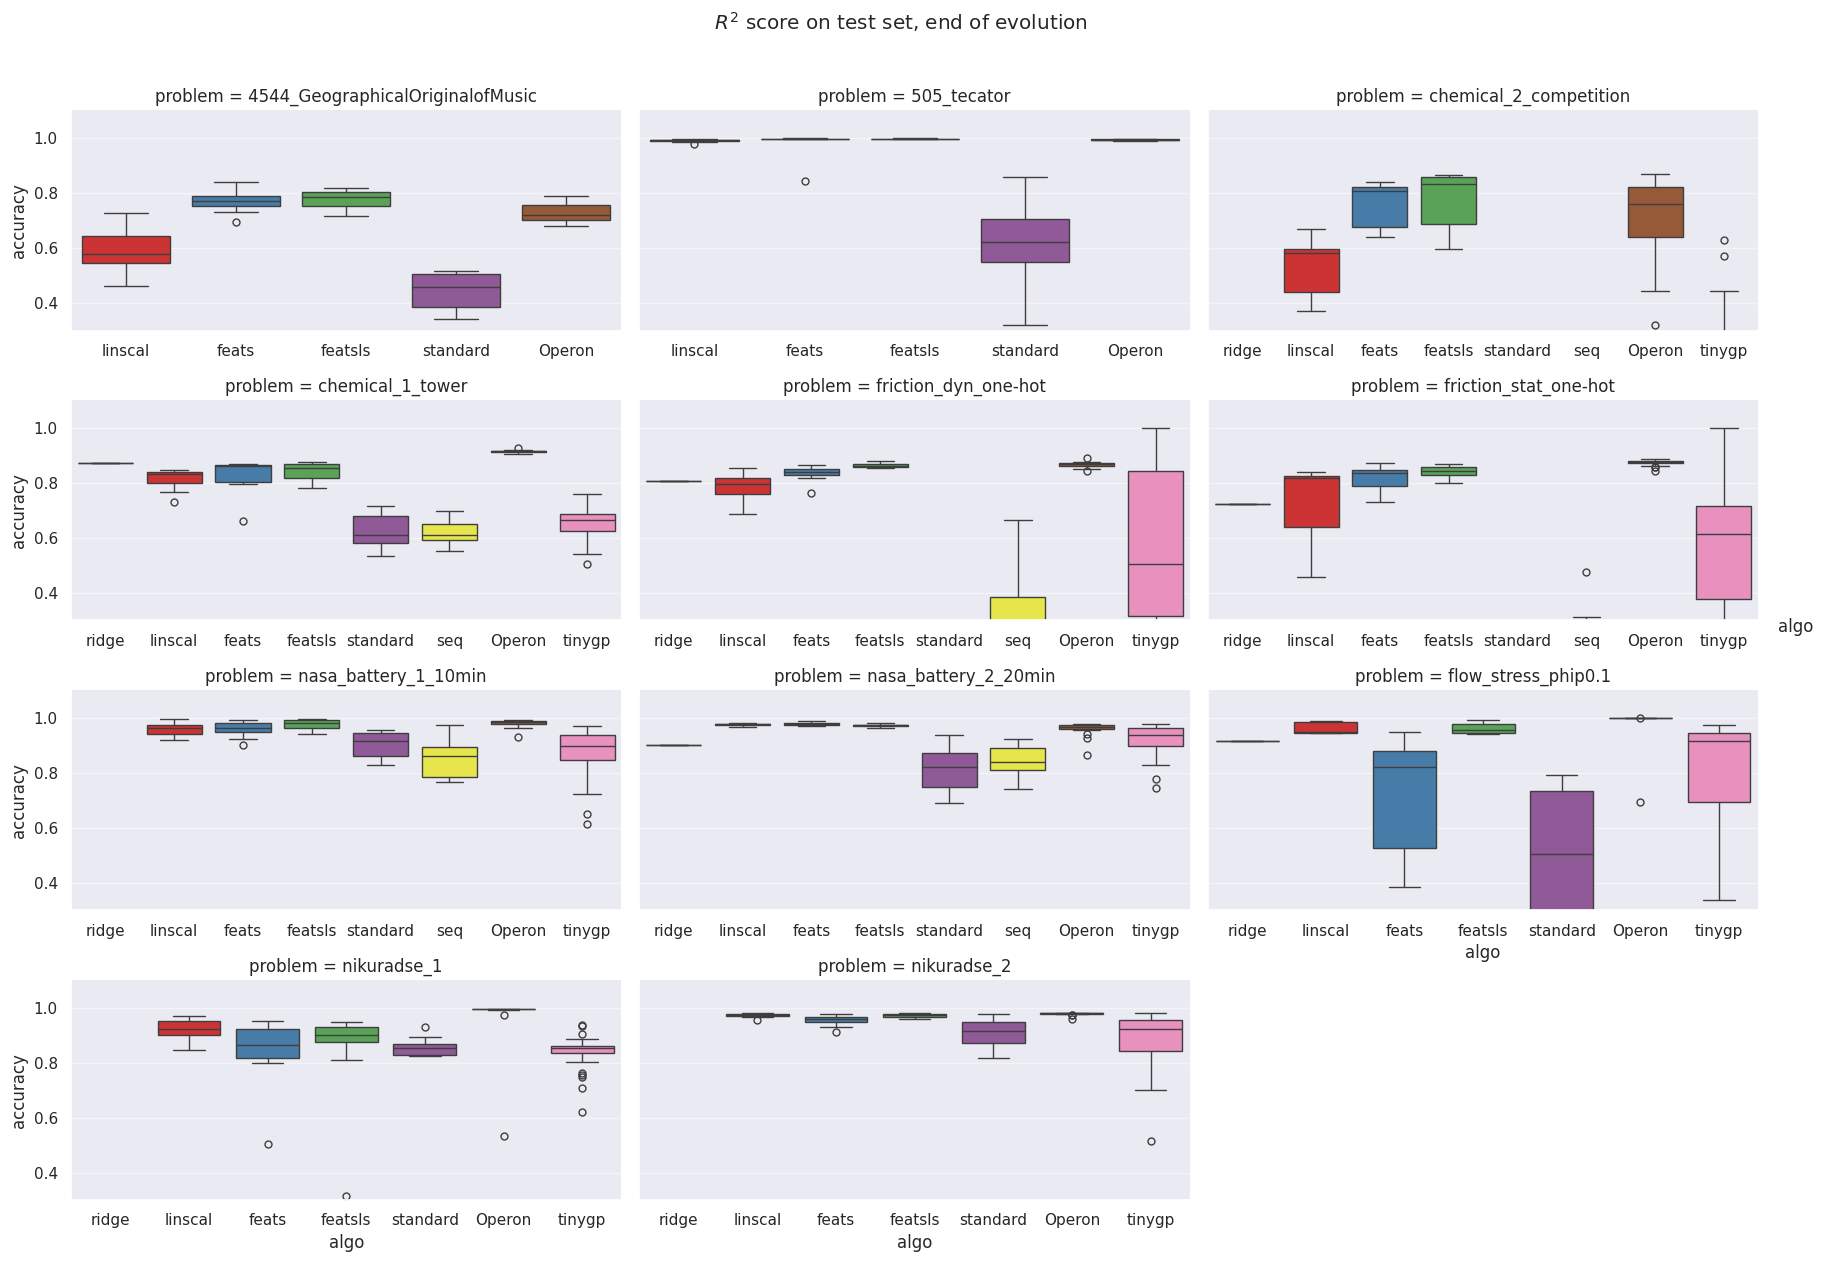

In [105]:
g = sns.catplot(x="algo", y="accuracy", hue="algo",
                data=final_df_and_baseline[final_df_and_baseline["method"] != "CGP_100"], col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(.3, 1.1)
plt.show()

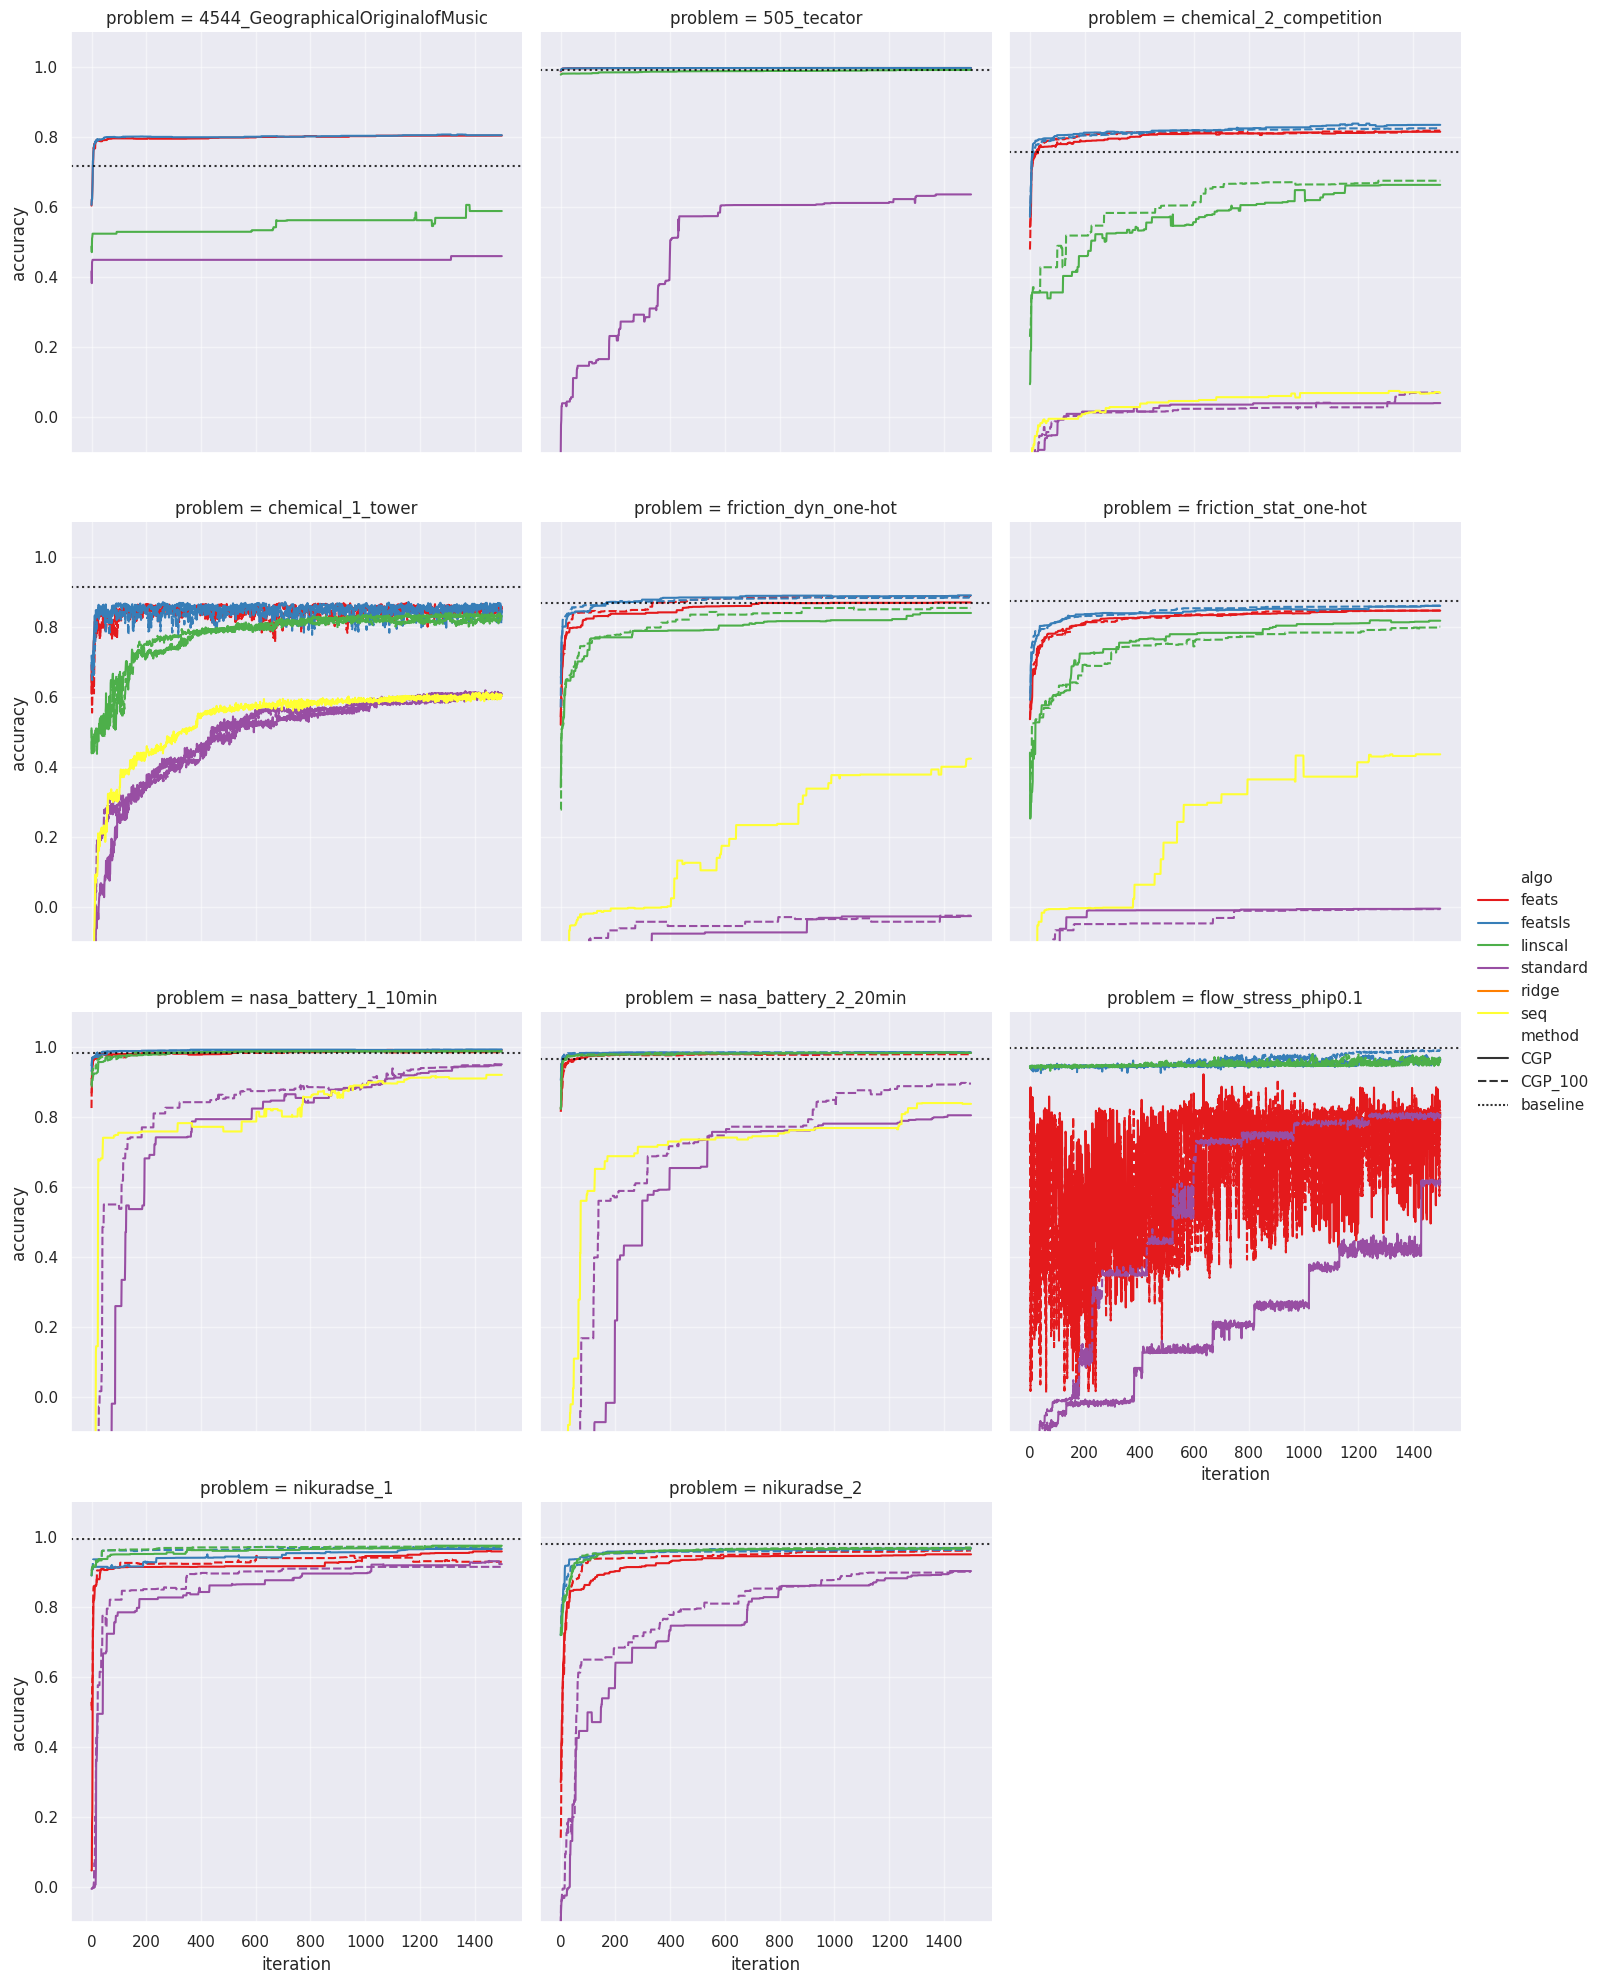

In [106]:
k = 50  # keep one point every 10 iterations
df_plot = (
    df[(df["when"] == "train") | (df["algo"] != "ridge")]
    .groupby(["problem", "algo", "method", "iteration"], as_index=False)
    .accuracy.median()
)
operon_medians = (
    final_df_and_baseline
    .query("algo == 'Operon'")
    .groupby("problem")["accuracy"]
    .median()
)

g = sns.relplot(data=df_plot, x="iteration", y="accuracy", hue="algo", col_wrap=3, style="method",
                col="problem", errorbar=None, kind="line", palette="Set1", col_order=problems)
for ax in g.axes.flat:
    problem = ax.get_title().split(" = ")[-1]  # extract problem name from facet title

    if problem in operon_medians.index:
        ax.axhline(
            y=operon_medians.loc[problem],
            linestyle=":",
            color="black",
            linewidth=1.5,
            alpha=0.8,
        )
plt.ylim(-.1, 1.1)
plt.show()

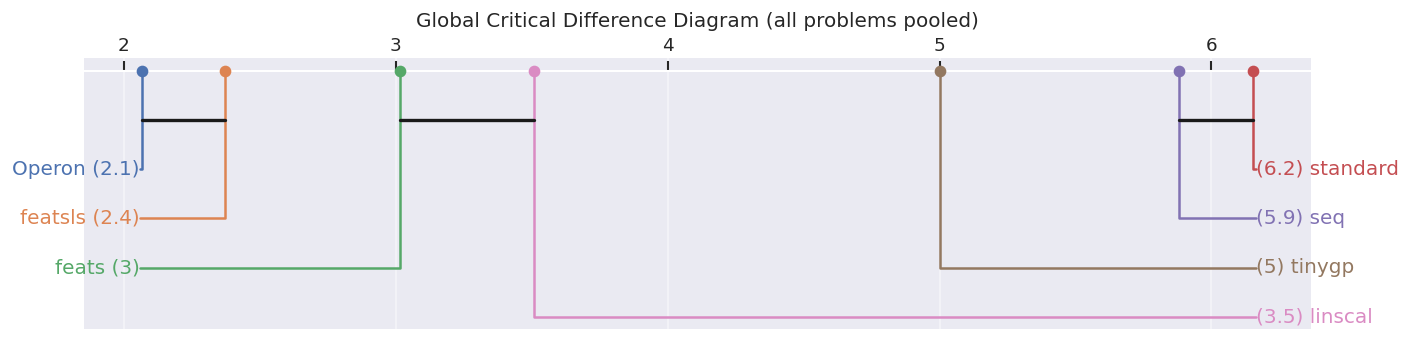

In [107]:
# -----------------------------
# 1. Copy + clean data
# -----------------------------
df = final_df_and_baseline.copy()
df = df[df["method"] != "CGP_100"]
df = df[df["algo"] != "ridge"]
df = df[["problem", "seed", "algo", "accuracy"]].copy()

# clean strings
df["algo"] = (
    df["algo"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

# enforce numeric types (important)
df["seed"] = pd.to_numeric(df["seed"], errors="raise")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="raise")

# -----------------------------
# 2. Build global block (problem + seed)
# -----------------------------
df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)

# -----------------------------
# 3. Pivot to wide format
# -----------------------------
df_wide = df.pivot(index="block", columns="algo", values="accuracy")

# optional: drop incomplete rows (safety)
df_wide = df_wide.dropna()

# -----------------------------
# 4. Compute average ranks (MAXIMIZATION)
# -----------------------------
avg_rank = df_wide.rank(axis=1, ascending=False).mean(axis=0)

# enforce consistent ordering
avg_rank = avg_rank.sort_values()

# -----------------------------
# 5. Posthoc Friedman
# -----------------------------
test_results = sp.posthoc_conover_friedman(df_wide)

# -----------------------------
# 6. Plot single CD diagram
# -----------------------------
plt.figure(figsize=(12, 3), dpi=120)
sp.critical_difference_diagram(avg_rank, test_results)

plt.title("Global Critical Difference Diagram (all problems pooled)")
plt.tight_layout()
plt.show()

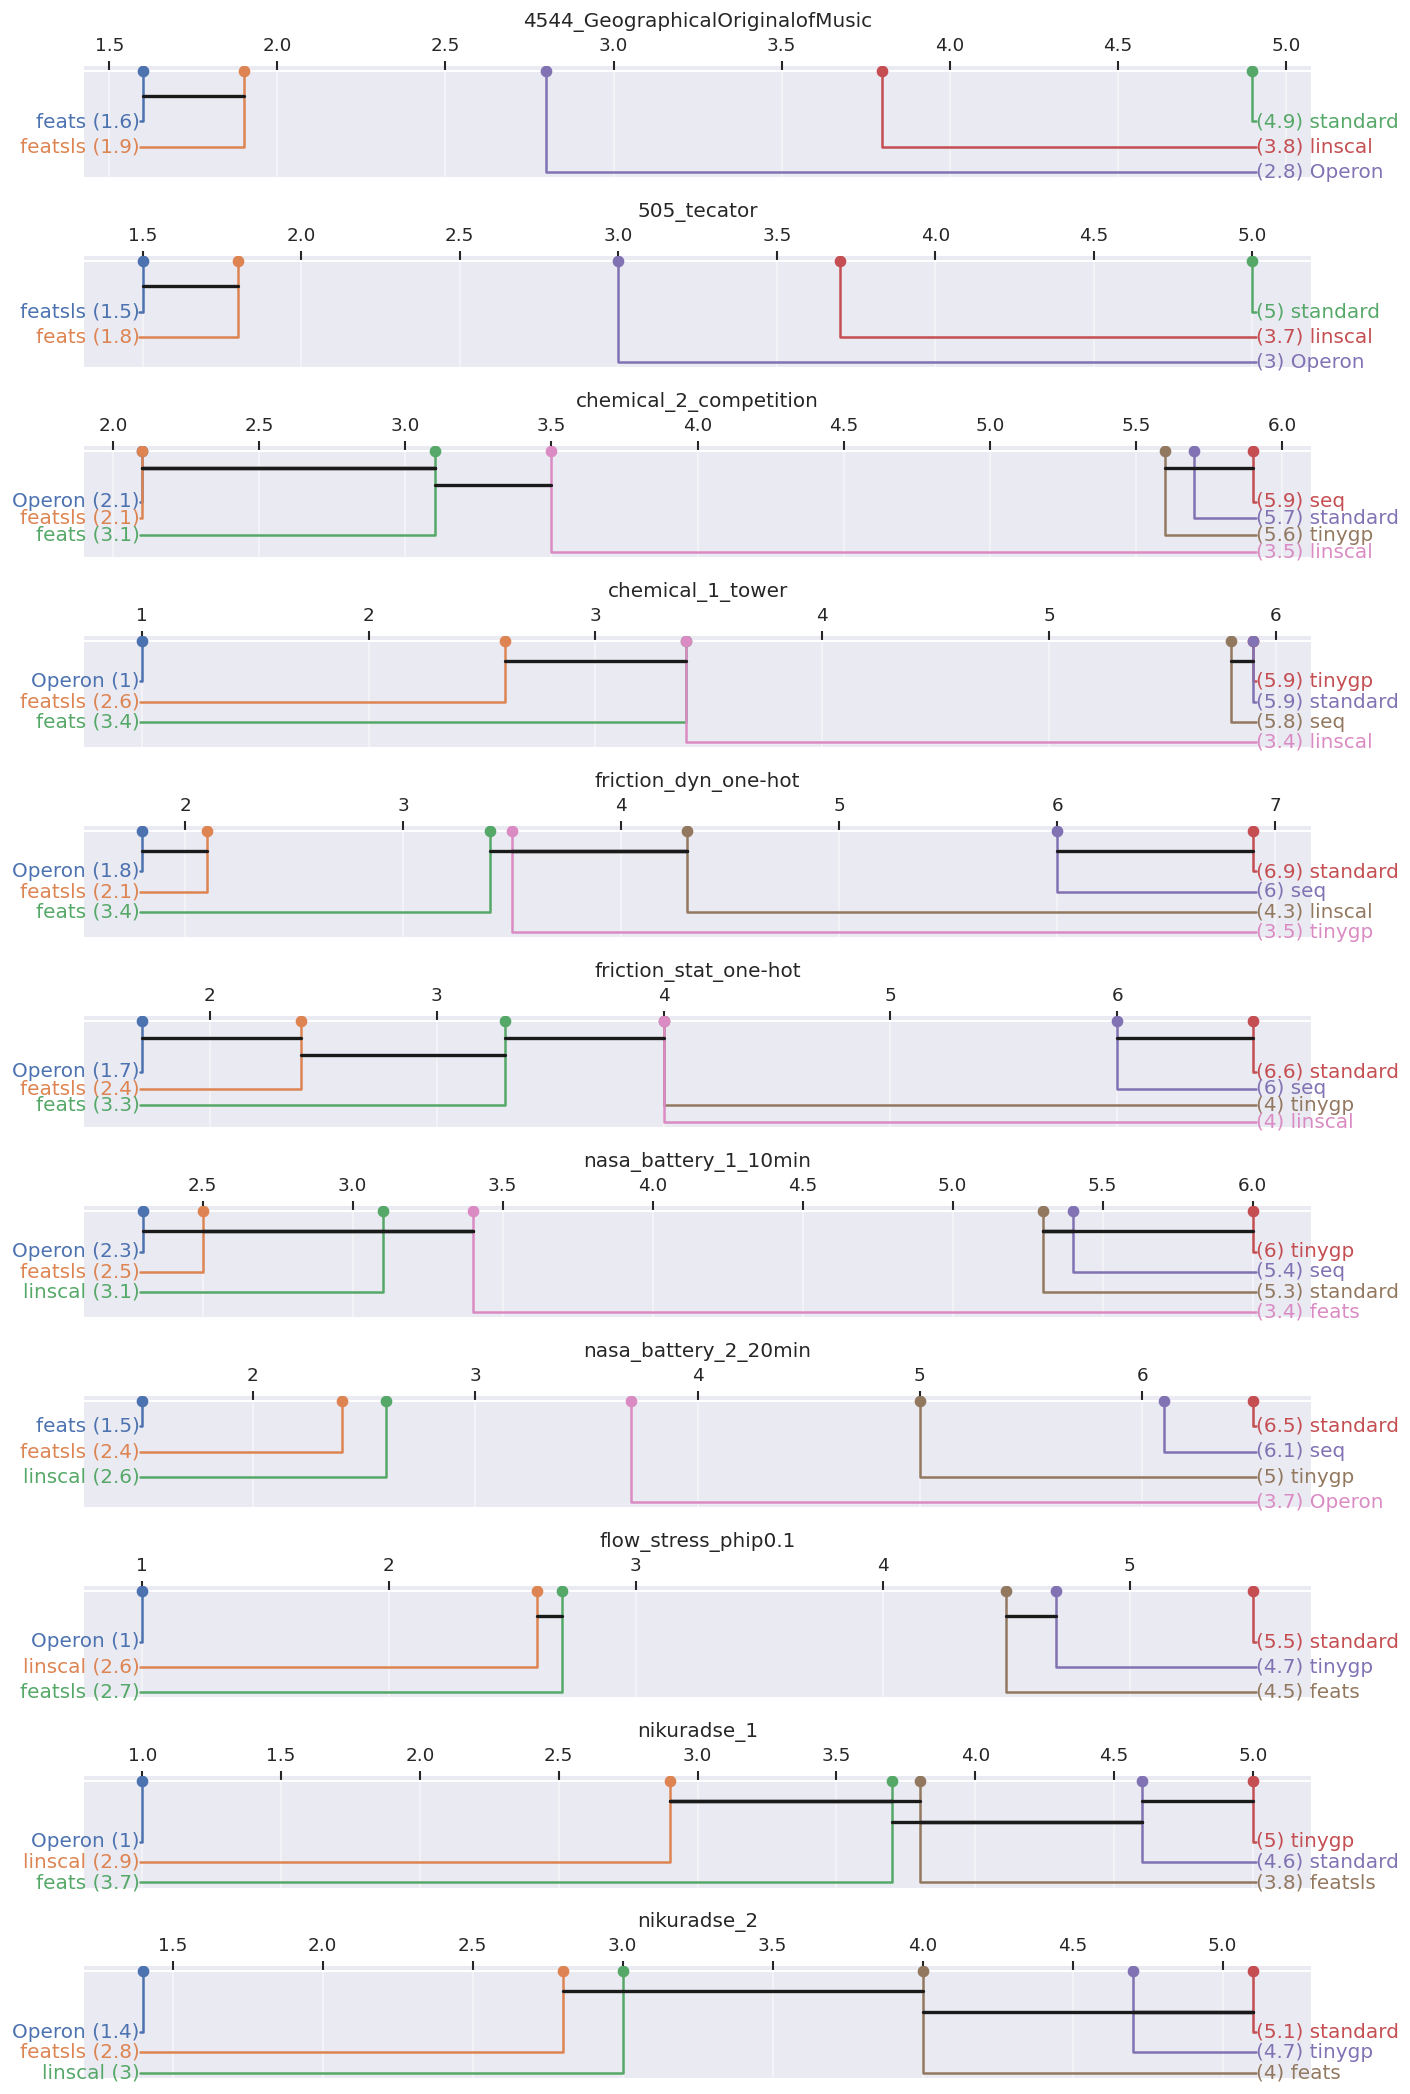

In [108]:
fig, axes = plt.subplots(
    nrows=len(problems),
    ncols=1,
    figsize=(12, 1.6 * len(problems)),
    dpi=120
)

if len(problems) == 1:
    axes = [axes]

for ax, problem in zip(axes, problems):
    df_tests = final_df_and_baseline[
        final_df_and_baseline["problem"] == problem
        ]
    df_tests = df_tests[df_tests["method"] != "CGP_100"]
    df_tests = df_tests[df_tests["algo"] != "ridge"]
    df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "accuracy"]]

    df_tests["algo"] = (
        df_tests["algo"]
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )

    df_wide = df_tests.pivot(index="seed", columns="algo", values="accuracy")

    # average ranks (this is correct for CD diagrams)
    rank = df_wide.rank(axis=1, ascending=False)
    avg_rank = rank.mean(axis=0)

    # posthoc
    test_results = sp.posthoc_conover_friedman(df_wide)

    # draw CD diagram
    plt.sca(ax)
    sp.critical_difference_diagram(
        avg_rank,
        test_results
    )

    ax.set_title(f"{problem}")

plt.tight_layout()
plt.show()

# Graph sizes

In [109]:
genome_sizes_df_1 = pd.read_csv("genome_analysis.csv")
genome_sizes_df_1["method"] = "CGP"
genome_sizes_df_2 = pd.read_csv("genome_analysis_100.csv")
genome_sizes_df_2["method"] = "CGP_100"
genome_sizes_df = pd.concat([genome_sizes_df_1, genome_sizes_df_2], ignore_index=True)
genome_sizes_df  #.head()

,problem,seed,algo,size,method
0,chemical_2_competition,0,seq,4,CGP
1,friction_dyn_one-hot,0,seq,9,CGP
2,friction_stat_one-hot,0,seq,8,CGP
3,nasa_battery_1_10min,0,seq,16,CGP
4,nasa_battery_2_20min,0,seq,15,CGP
...,...,...,...,...,...
775,nasa_battery_2_20min,9,baseline,15,CGP_100
776,nikuradse_1,9,baseline,15,CGP_100
777,nikuradse_2,9,baseline,17,CGP_100
778,chemical_1_tower,9,baseline,10,CGP_100


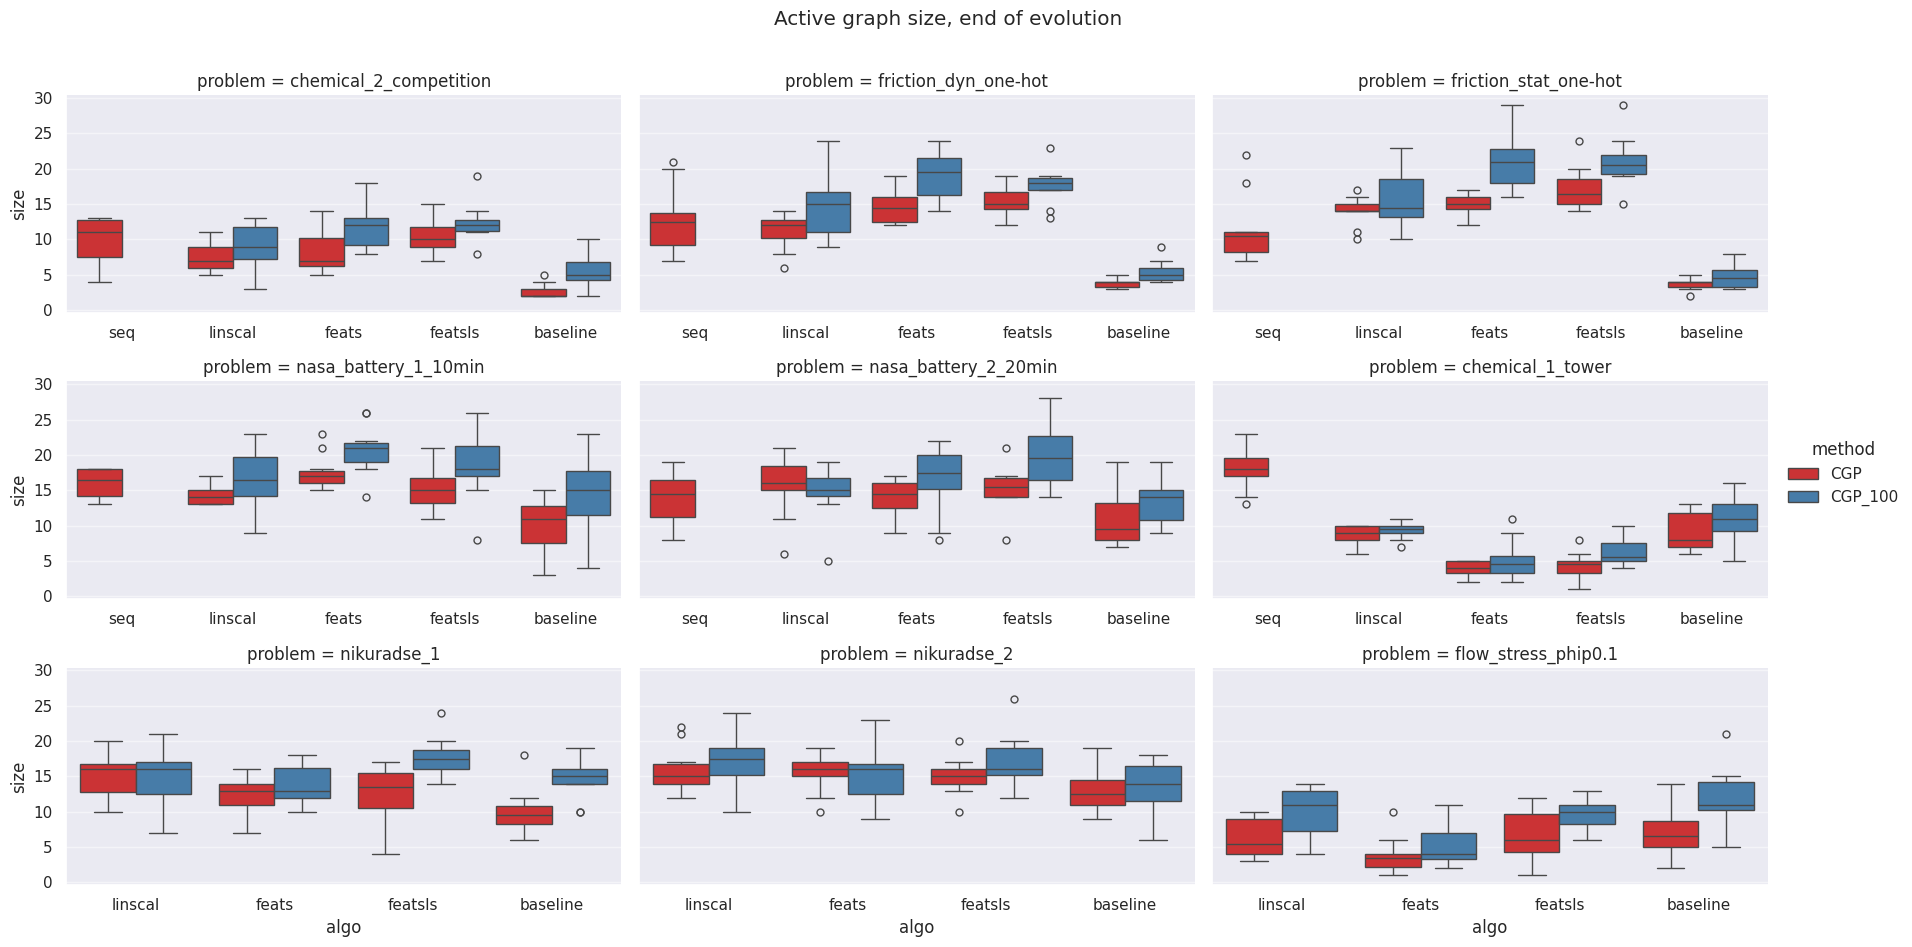

In [110]:
g = sns.catplot(hue="method", y="size", x="algo", data=genome_sizes_df, col="problem", col_wrap=3,
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("Active graph size, end of evolution", y=1.05)  # Add title above the plot
# plt.ylim(-.3, 1.1)
plt.show()

In [111]:
# # -----------------------------
# # 1. Copy + clean data
# # -----------------------------
# df = genome_sizes_df.copy()
# df = df[["problem", "seed", "algo", "size"]].copy()
#
# # clean strings
# df["algo"] = (
#     df["algo"]
#     .astype(str)
#     .str.replace("\n", " ", regex=False)
#     .str.strip()
# )
#
# # enforce numeric types (important)
# df["seed"] = pd.to_numeric(df["seed"], errors="raise")
# df["size"] = pd.to_numeric(df["size"], errors="raise")
#
# # -----------------------------
# # 2. Build global block (problem + seed)
# # -----------------------------
# df["block"] = df["problem"].astype(str) + "_seed_" + df["seed"].astype(str)
#
# # -----------------------------
# # 3. Pivot to wide format
# # -----------------------------
# df_wide = df.pivot(index="block", columns="algo", values="size")
#
# # optional: drop incomplete rows (safety)
# df_wide = df_wide.dropna()
#
# # -----------------------------
# # 4. Compute average ranks (MAXIMIZATION)
# # -----------------------------
# avg_rank = df_wide.rank(axis=1, ascending=True).mean(axis=0)
#
# # enforce consistent ordering
# avg_rank = avg_rank.sort_values()
#
# # -----------------------------
# # 5. Posthoc Friedman
# # -----------------------------
# test_results = sp.posthoc_conover_friedman(df_wide)
#
# # -----------------------------
# # 6. Plot single CD diagram
# # -----------------------------
# plt.figure(figsize=(12, 3), dpi=120)
# sp.critical_difference_diagram(avg_rank, test_results)
#
# plt.title("Global Critical Difference Diagram of Sizes (all problems pooled)")
# plt.tight_layout()
# plt.show()

In [112]:
# fig, axes = plt.subplots(
#     nrows=len(genome_sizes_df["problem"].unique()),
#     ncols=1,
#     figsize=(12, 1.6 * len(genome_sizes_df["problem"].unique())),
#     dpi=120
# )
#
# if len(genome_sizes_df["problem"].unique()) == 1:
#     axes = [axes]
#
# for ax, problem in zip(axes, genome_sizes_df["problem"].unique()):
#     df_tests = genome_sizes_df[
#         genome_sizes_df["problem"] == problem
#         ]
#
#     df_tests = df_tests[df_tests["seed"] < 10][["seed", "algo", "size"]]
#
#     df_tests["algo"] = (
#         df_tests["algo"]
#         .str.replace("\n", " ", regex=False)
#         .str.strip()
#     )
#
#     df_wide = df_tests.pivot(index="seed", columns="algo", values="size")
#
#     # average ranks (this is correct for CD diagrams)
#     rank = df_wide.rank(axis=1, ascending=True)
#     avg_rank = rank.mean(axis=0)
#
#     # posthoc
#     test_results = sp.posthoc_conover_friedman(df_wide)
#
#     # draw CD diagram
#     plt.sca(ax)
#     sp.critical_difference_diagram(
#         avg_rank,
#         test_results
#     )
#
#     ax.set_title(f"{problem}")
#
# plt.tight_layout()
# plt.show()

# Sensitivity of features number

In [113]:
sensitivity_dfs = []
problem = "chemical_2_competition"
for n_feats in range(2, 58, 2):
    for seed in range(30):
        for extra in ['feats', 'featsls']:
            path = f"../results/sensitivity/CGP_{extra}_{problem}_{seed}_{n_feats}"
            if n_feats == 8:
                path = path.replace("/sensitivity", "").replace("_8", "")
            if os.path.exists(f"{path}.pickle"):
                tmp_df = pd.read_csv(f"{path}.csv")
                tmp_df["seed"] = seed
                tmp_df["problem"] = problem
                tmp_df["n_features"] = n_feats
                tmp_df["algo"] = f"CGP \n {extra}"
                tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                sensitivity_dfs.append(tmp_df)
sensitivity_df = pd.concat(sensitivity_dfs, ignore_index=True)
sensitivity_df["test_accuracy"] = sensitivity_df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
sensitivity_df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,n_features,algo,total_time
0,0,0.306892,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0
1,1,0.306892,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1
2,2,0.306892,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2
3,3,0.306892,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3
4,4,0.306892,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4


In [114]:
sensitivity_df1 = copy(sensitivity_df)
sensitivity_df2 = copy(sensitivity_df)
sensitivity_df1 = sensitivity_df1.rename(columns={"test_accuracy": "accuracy"})
sensitivity_df2 = sensitivity_df2.rename(columns={"max_fitness": "accuracy"})
sensitivity_df1 = sensitivity_df1.drop(columns=["max_fitness"])
sensitivity_df2 = sensitivity_df2.drop(columns=["test_accuracy"])
sensitivity_df1["when"] = "test"
sensitivity_df2["when"] = "train"
sensitivity_df = pd.concat([sensitivity_df1, sensitivity_df2], ignore_index=True)
sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,0,0.000000,0.059002,0,chemical_2_competition,2,CGP \n feats,0,test
1,1,1.660011,0.059002,0,chemical_2_competition,2,CGP \n feats,1,test
2,2,0.858455,0.059002,0,chemical_2_competition,2,CGP \n feats,2,test
3,3,0.914011,0.059002,0,chemical_2_competition,2,CGP \n feats,3,test
4,4,0.949023,0.059002,0,chemical_2_competition,2,CGP \n feats,4,test


In [115]:
final_sensitivity_df = sensitivity_df[sensitivity_df["iteration"] == max(sensitivity_df["iteration"])].reset_index(
    drop=True)
final_sensitivity_df.head()

,iteration,time,accuracy,seed,problem,n_features,algo,total_time,when
0,1499,0.996661,0.622282,0,chemical_2_competition,2,CGP \n feats,1488,test
1,1499,0.963794,0.521470,0,chemical_2_competition,2,CGP \n featsls,1407,test
2,1499,1.070991,0.768297,1,chemical_2_competition,2,CGP \n feats,1691,test
3,1499,1.105551,0.757006,1,chemical_2_competition,2,CGP \n featsls,1708,test
4,1499,1.098661,0.656548,2,chemical_2_competition,2,CGP \n feats,1830,test


In [116]:
sensitivity_sizes_df = pd.read_csv("genome_analysis_sensitivity.csv")
base_size = genome_sizes_df[
    (genome_sizes_df["problem"] == "chemical_2_competition") &
    (genome_sizes_df["algo"].isin(["feats", "featsls"]))
    ]
base_size = base_size.drop(columns=["method"], inplace=False)
base_size["n_features"] = 8
sensitivity_sizes_df = pd.concat([sensitivity_sizes_df, base_size], ignore_index=True)
sensitivity_sizes_df.head()

,problem,seed,algo,size,n_features
0,chemical_2_competition,0,feats,7,2
1,chemical_2_competition,0,feats,10,4
2,chemical_2_competition,0,feats,14,6
3,chemical_2_competition,0,feats,7,10
4,chemical_2_competition,0,feats,9,12


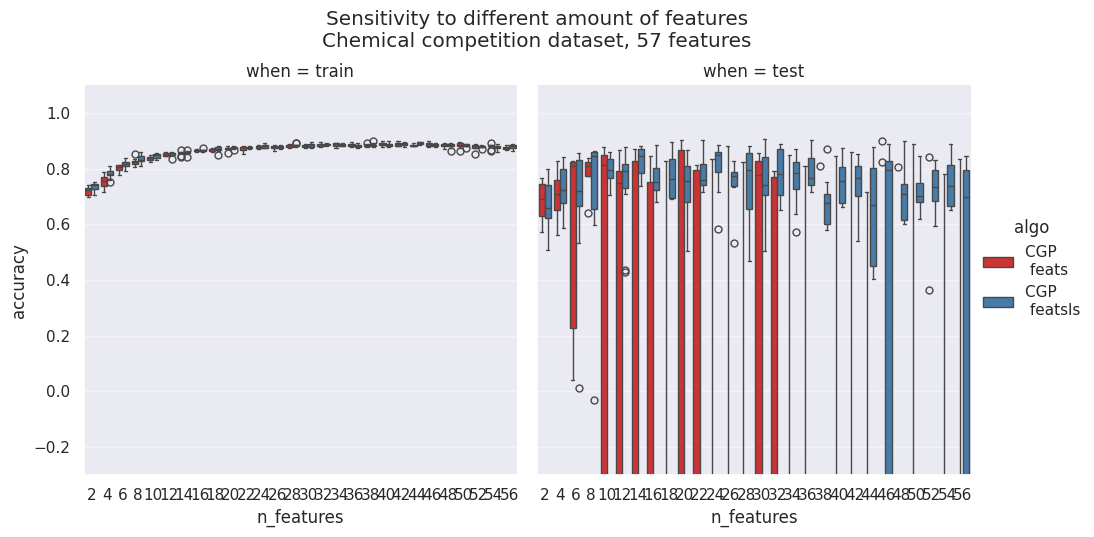

In [117]:
g = sns.catplot(x="n_features",
                y="accuracy",
                hue="algo",
                data=final_sensitivity_df,
                # col="problem",
                col_order=["train", "test"],
                col="when",
                kind="box", palette="Set1", sharex=True)  #height=3, aspect=2,
g.figure.suptitle("Sensitivity to different amount of features\nChemical competition dataset, 57 features", y=1.07)
plt.ylim(-.3, 1.1)
plt.show()

In [118]:
cgp_medians = (
    final_df_and_baseline[
        (final_df_and_baseline["method"] == "CGP") &
        (final_df_and_baseline["algo"] == "standard")
        ]
    .groupby("problem")["accuracy"]
    .median()
)

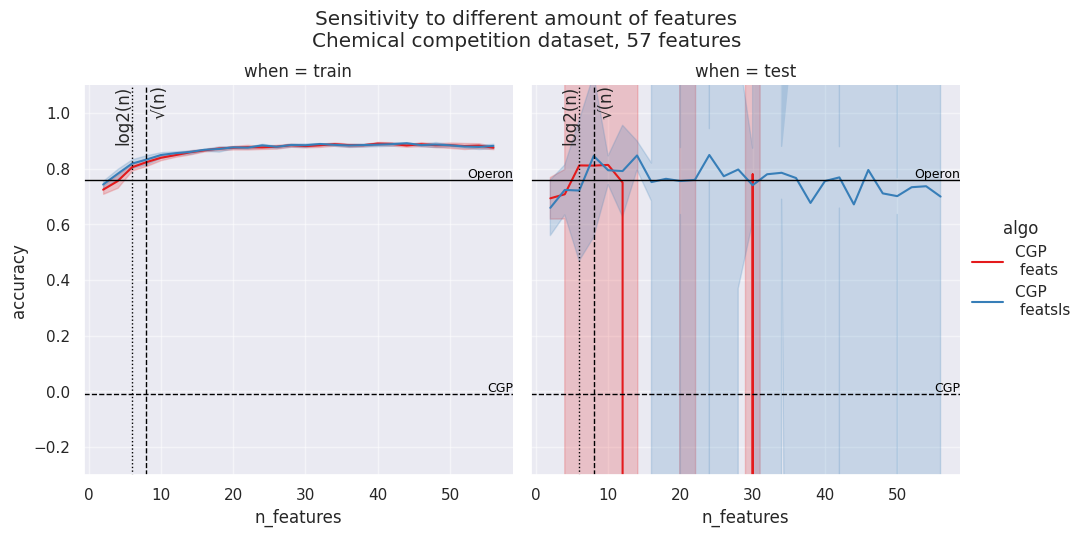

In [119]:
g = sns.relplot(
    data=final_sensitivity_df,
    x="n_features",
    y="accuracy",
    hue="algo",
    # col="problem",
    col="when",
    col_order=["train", "test"],
    kind="line",
    estimator="median",  # plot the mean
    errorbar="sd",  # shaded ±1 standard deviation
    # or errorbar=("ci", 95) for 95% confidence interval
    palette="Set1",
)
for ax in g.axes.flat:
    ax.axvline(x=6, linestyle=":", color="black", linewidth=1)
    ax.axvline(x=8, linestyle="--", color="black", linewidth=1)
    ax.axhline(y=operon_medians["chemical_2_competition"], color="black", linewidth=1)
    ax.axhline(y=cgp_medians["chemical_2_competition"], linestyle="--", color="black", linewidth=1)
    x_max = ax.get_xlim()[1]
    ax.text(
        x_max,
        operon_medians["chemical_2_competition"],
        "Operon",
        va="bottom",
        ha="right",
        fontsize=9,
        color="black",
    )
    ax.text(
        x_max,
        cgp_medians["chemical_2_competition"],
        "CGP",
        va="bottom",
        ha="right",
        fontsize=9,
        color="black",
    )
    ax.annotate(
        "log2(n)",
        xy=(6, 1),
        xytext=(3.5, 1.1),
        textcoords="data",
        rotation=90,
        va="top"
    )
    ax.annotate(
        "√(n)",
        xy=(8, 1),
        xytext=(8.5, 1.1),
        textcoords="data",
        rotation=90,
        va="top"
    )

g.figure.suptitle("Sensitivity to different amount of features\nChemical competition dataset, 57 features", y=1.07)
g.set(ylim=(-0.3, 1.1))
plt.show()

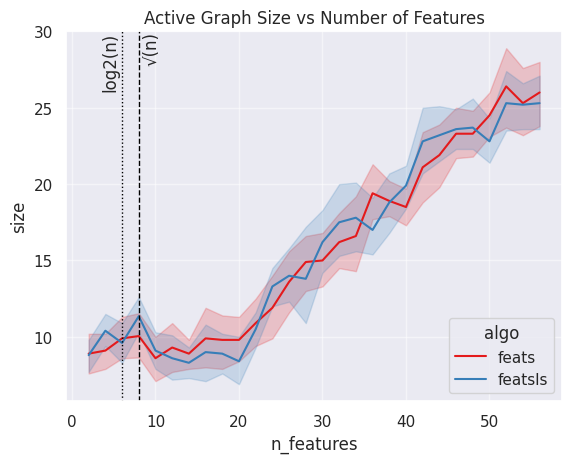

In [120]:
ax = sns.lineplot(sensitivity_sizes_df, x="n_features", y="size", hue="algo", palette="Set1")
ax.axvline(x=6, linestyle=":", color="black", linewidth=1)
ax.axvline(x=8, linestyle="--", color="black", linewidth=1)
ax.annotate(
    "log2(n)",
    xy=(6, 30),
    xytext=(3.5, 30),
    textcoords="data",
    rotation=90,
    va="top"
)
ax.annotate(
    "√(n)",
    xy=(8, 30),
    xytext=(8.5, 30),
    textcoords="data",
    rotation=90,
    va="top"
)
ax.set_title("Active Graph Size vs Number of Features")
plt.show()

In [133]:
# case for small datasets
small_dfs = []
for problem in ["nikuradse_1", "nikuradse_2"]:
    for seed in range(30):
        for method in ["CGP", "CGP_wide"]:
            for extra in ['linscal', 'feats', 'featsls', 'baseline']:
                if os.path.exists(f"../results/{method}_{extra}_{problem}_{seed}.pickle"):
                    tmp_df = pd.read_csv(f"../results/{method}_{extra}_{problem}_{seed}.csv")
                    tmp_df["seed"] = seed
                    tmp_df["problem"] = problem
                    tmp_df["algo"] = extra.replace("baseline", "standard")
                    tmp_df["method"] = method
                    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                    small_dfs.append(tmp_df)
small_df = pd.concat(small_dfs, ignore_index=True)
small_df["test_accuracy"] = small_df["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(float)
small_df.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,method,total_time
0,0,0.964169,0.000000,0.856621,0,nikuradse_1,linscal,CGP,0
1,1,0.964550,1.547324,0.851236,0,nikuradse_1,linscal,CGP,1
2,2,0.964550,0.631808,0.851236,0,nikuradse_1,linscal,CGP,2
3,3,0.964550,0.673278,0.851236,0,nikuradse_1,linscal,CGP,2
4,4,0.964550,0.695490,0.851236,0,nikuradse_1,linscal,CGP,3


In [134]:
df1 = copy(small_df)
df2 = copy(small_df)
df1 = df1.rename(columns={"test_accuracy": "accuracy"})
df2 = df2.rename(columns={"max_fitness": "accuracy"})
df1 = df1.drop(columns=["max_fitness"])
df2 = df2.drop(columns=["test_accuracy"])
df1["when"] = "test"
df2["when"] = "train"
small_df = pd.concat([df1, df2], ignore_index=True)
max_iter = small_df.groupby(["algo", "problem"])["iteration"].transform("max")
final_small_df = small_df[small_df["iteration"] == max_iter].reset_index(drop=True)
final_small_df_for_baseline_merge = final_small_df[final_small_df["when"] == "test"][
    ["seed", "algo", "method", "problem", "accuracy"]]
baselines_df_filtered_small = baselines_df[baselines_df["problem"].isin(final_small_df_for_baseline_merge["problem"])]
final_df_and_baseline_small = pd.concat([final_small_df_for_baseline_merge, baselines_df_filtered_small],
                                        ignore_index=True)

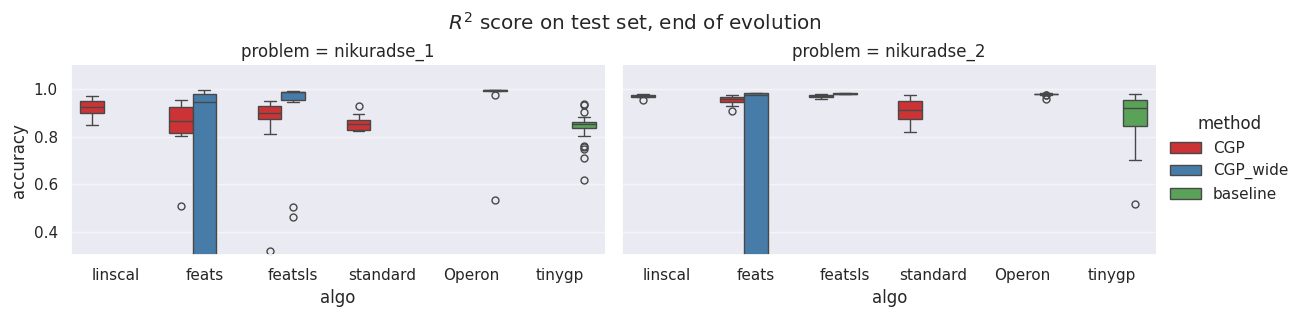

In [135]:
g = sns.catplot(hue="method", y="accuracy", x="algo", data=final_df_and_baseline_small, col="problem",
                kind="box", palette="Set1", height=3, aspect=2, sharex=False)
g.figure.suptitle("$R^2$ score on test set, end of evolution", y=1.05)  # Add title above the plot
plt.ylim(.3, 1.1)
plt.show()


# General introduction (Classification)
## Idea
Same idea presented for symbolic regression; we use logistic regression for predicting the target $y$ from the features $X'$ (rather than from the raw features $X$).

## Problems considered
| Dataset                   | Features | Samples |
|---------------------------|----------|---------|
| Hill Valley without Noise | 100      | 1212    |
| Hill Valley with Noise    | 100      | 1212    |
| Clean 1                   | 168      | 476     |

## Baselines
- Logistic regression from $X$ to $y$ $\rightarrow$ `logistic`

## CGP versions considered
- Standard CGP (from $X$ to $y$) $\rightarrow$ `standard`
- CGP used for feature construction ($X$ to $X'$) followed by Logistic regression ($X'$ to $y$) $\rightarrow$ `feats`

## Number of features
By default, the number of intermediate features $|X'|$ is set by default to max(5,round$(\sqrt{|X|})$).

In [79]:
dfs_class = []
class_problems = ['Hill_Valley_with_noise', 'Hill_Valley_without_noise', 'clean1']
for problem in class_problems:
    for seed in range(30):
        for method in ["CGP"]:
            for extra in ['feats', 'baseline']:
                if os.path.exists(f"../results/{method}_{extra}_{problem}_{seed}.pickle"):
                    tmp_df = pd.read_csv(f"../results/{method}_{extra}_{problem}_{seed}.csv")
                    tmp_df["seed"] = seed
                    tmp_df["problem"] = problem
                    tmp_df["algo"] = extra.replace("baseline", "standard")
                    tmp_df["method"] = method
                    tmp_df["total_time"] = tmp_df["time"].cumsum().astype(int)
                    dfs_class.append(tmp_df)
df_classification = pd.concat(dfs_class, ignore_index=True)
df_classification["test_accuracy"] = df_classification["test_accuracy"].str.replace(r"[\[\]]", "", regex=True).astype(
    float)
df_classification.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,method,total_time
0,0,0.563256,0.000000,0.541254,0,Hill_Valley_with_noise,feats,CGP,0
1,1,0.651265,5.855316,0.603960,0,Hill_Valley_with_noise,feats,CGP,5
2,2,0.651265,2.611994,0.603960,0,Hill_Valley_with_noise,feats,CGP,8
3,3,0.651265,2.601232,0.620462,0,Hill_Valley_with_noise,feats,CGP,11
4,4,0.651265,2.655534,0.603960,0,Hill_Valley_with_noise,feats,CGP,13


In [80]:
max_iter = (
    df_classification.groupby(["problem", "algo"])["iteration"]
    .max()
    .unstack()
)
max_iter["iteration_multiplier"] = max_iter["standard"] / max_iter["feats"]
result = max_iter.reset_index()
df_classification = df_classification.merge(
    result[["problem", "iteration_multiplier"]],
    on="problem",
    how="left"
)
df_classification["adjusted_iteration"] = np.where(
    df_classification["algo"] == "feats",
    df_classification["iteration"] * df_classification["iteration_multiplier"],
    df_classification["iteration"]
)

In [81]:
max_iter = df_classification.groupby(["algo", "problem"])["iteration"].transform("max")
final_df_class = df_classification[df_classification["iteration"] == max_iter].reset_index(drop=True)
final_df_class.head()

,iteration,max_fitness,time,test_accuracy,seed,problem,algo,method,total_time,iteration_multiplier,adjusted_iteration
0,330,0.789879,2.500530,0.749175,0,Hill_Valley_with_noise,feats,CGP,848,4.542424,1499.0
1,1499,0.740374,0.881741,0.679868,0,Hill_Valley_with_noise,standard,CGP,1289,4.542424,1499.0
2,330,0.793179,2.534209,0.765677,1,Hill_Valley_with_noise,feats,CGP,863,4.542424,1499.0
3,1499,0.803080,0.920531,0.772277,1,Hill_Valley_with_noise,standard,CGP,1384,4.542424,1499.0
4,330,0.770077,2.594288,0.689769,2,Hill_Valley_with_noise,feats,CGP,878,4.542424,1499.0


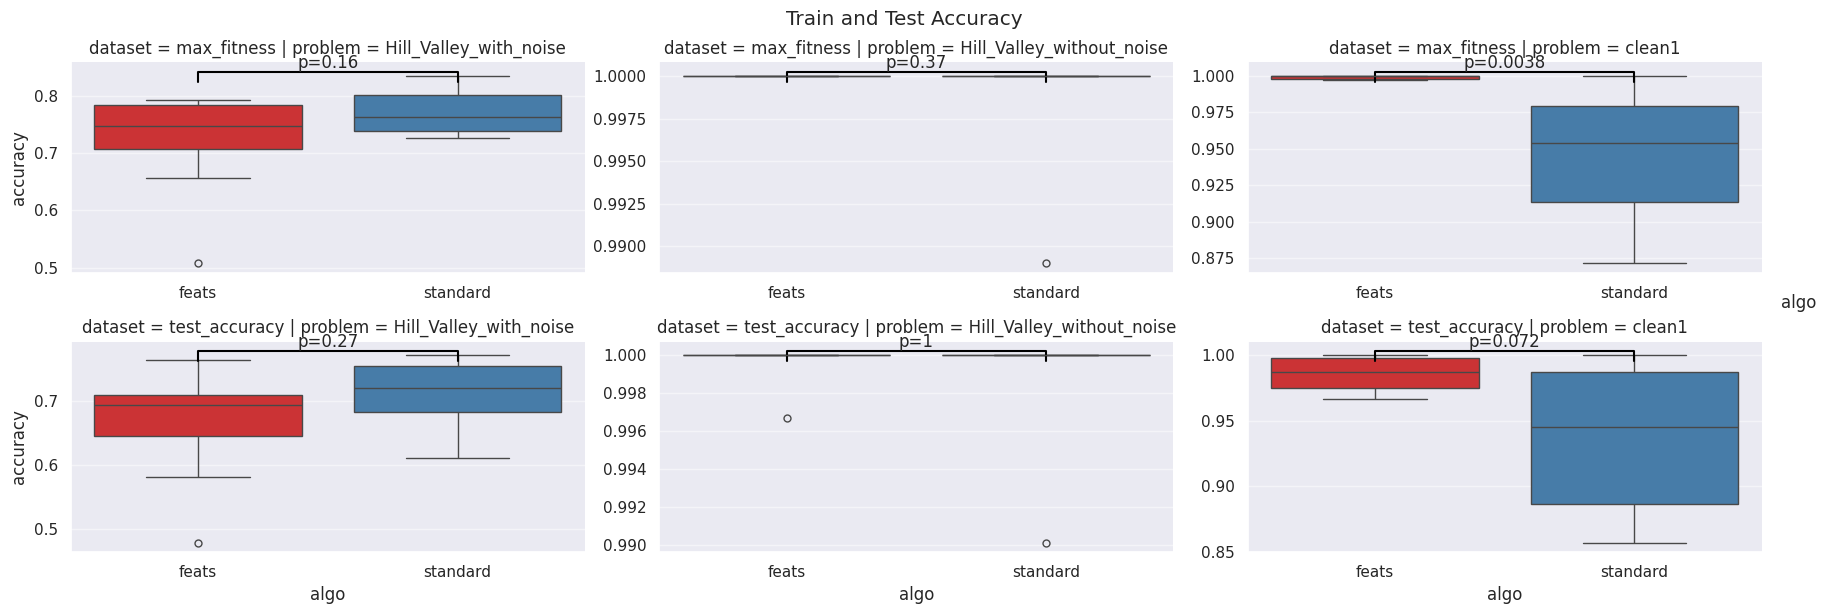

In [82]:
df_long = final_df_class.melt(
    id_vars=["algo", "problem"],
    value_vars=["max_fitness", "test_accuracy"],
    var_name="dataset",
    value_name="accuracy"
)

g = sns.catplot(
    data=df_long,
    x="algo",
    y="accuracy",
    hue="algo",
    col="problem",
    row="dataset",
    sharey=False,
    kind="box",
    palette="Set1",
    height=3,
    aspect=2,
    sharex=False
)

algos = sorted(df_long["algo"].unique())

for i, dataset in enumerate(g.row_names):
    for j, problem in enumerate(g.col_names):
        ax = g.axes[i, j]

        subset = df_long[
            (df_long["dataset"] == dataset) &
            (df_long["problem"] == problem)
            ]

        g1 = subset.loc[subset["algo"] == algos[0], "accuracy"]
        g2 = subset.loc[subset["algo"] == algos[1], "accuracy"]

        # Mann-Whitney test
        stat, p = mannwhitneyu(g1, g2, alternative="two-sided")

        # Position annotation
        ymin, ymax = ax.get_ylim()
        h = (ymax - ymin) * 0.05
        y = ymax - h * 1.5

        # significance bar
        ax.plot([0, 0, 1, 1],
                [y, y + h, y + h, y],
                lw=1.5, c='black')

        ax.text(
            0.5,
            y + h,
            f"p={p:.2g}",
            ha='center',
            va='bottom'
        )

g.figure.suptitle("Train and Test Accuracy", y=1.02)

plt.show()

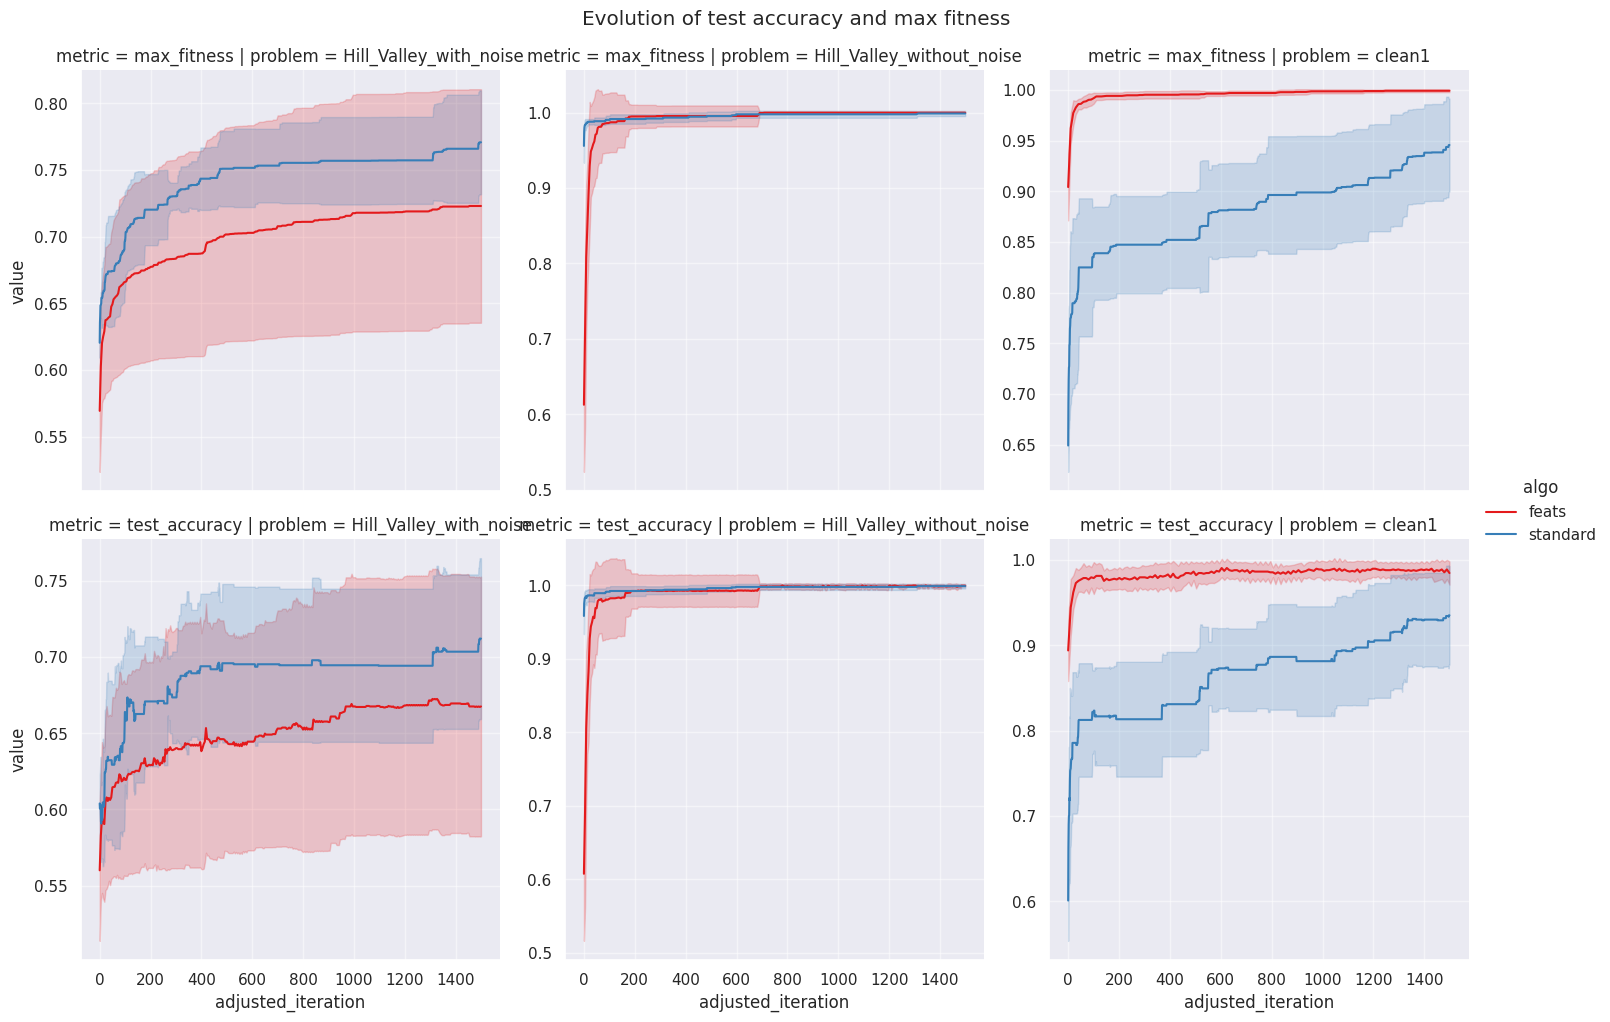

In [83]:
df_long = df_classification.melt(
    id_vars=["adjusted_iteration", "algo", "problem"],
    value_vars=["max_fitness", "test_accuracy"],  # max_fitness first
    var_name="metric",
    value_name="value"
)

g = sns.relplot(
    data=df_long,
    x="adjusted_iteration",
    y="value",
    hue="algo",
    col="problem",
    row="metric",
    kind="line",
    errorbar="sd",
    palette="Set1",
    facet_kws={"sharey": False}
)

g.figure.suptitle("Evolution of test accuracy and max fitness", y=1.02)

plt.show()